### The Mechanics of learning 

In [1]:
#import libraries 
import torch 
import torch.optim as optim
from matplotlib import pyplot as plt 

In [2]:
# Gathering data 

t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0, 3.0, -4.0, 6.0, 13.0, 21.0] # temperature in celsius 
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4] # temperature in unknown unit 

t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

def model(t_u, w, b): #defining model 
    return w * t_u + b 

def loss_fn(t_p, t_c): # defining the losss function
    squaured_diffs = (t_p - t_c)**2 
    return squaured_diffs.mean()  # mean square loss

# intializing parameters 
w = torch.ones(()) 
b = torch.zeros(())

# running model 
t_p = model(t_u, w, b)
print(t_p)

# calculating loss 
loss = loss_fn(t_p, t_c) 
print(loss)


tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])
tensor(1763.8846)


In [3]:
# decrease loss:
"""
The idea is to compute the rate of change of the loss with respect to each parameter and modify each parameter in direction of decreasing loss. 
"""
delta = 0.1
learning_rate = 1e-2

loss_rate_of_change_w =(loss_fn(model(t_u, w + delta, b),t_c) - loss_fn(model(t_u, w-delta, b), t_c)) / (2.0 * delta)
w = w - learning_rate * loss_rate_of_change_w 

loss_rate_of_change_b = (loss_fn(model(t_u, w, b + delta), t_c) - loss_fn(model(t_u, w, b - delta), t_c))/ (2.0 * delta)
b = b - learning_rate * loss_rate_of_change_b


In [4]:
#computing the derivatives and applying it to models
def dloss_fn(t_p, t_c):
    dsquared_diffs = 2 * (t_p - t_c) / t_p.size(0) #the division is from the derivative of mean. 
    return dsquared_diffs

def dmodel_dw(t_u, w, b):
    return t_u 

def dmodel_db(t_u, w, b):
    return 1.0

#defining the gradient function
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()]) #summation us the reverse if the broadcasting we implicitly do when applying the parameters to an entire vector of inputs in the model. 





In [5]:
# Iterating to fit the model 
# training loop 
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        w, b = params 
        t_p = model(t_u, w, b)  #forward pass  
        loss = loss_fn(t_p, t_c) 
        grad = grad_fn(t_u, t_c, t_p, w, b) #backward pass
        params = params - learning_rate * grad 

        if epoch in {1,2,3,10,11,99,100, 4000, 5000, 40000, 50000}:
            print("Epoch %d, Loss %f" %(epoch, float(loss)))
            print('     Params:', params)
            print('     Grad:  ', grad)
        if epoch in {4,12, 101}:
            print('...')
        if not torch.isfinite(loss).all():
            break 

    return params

training_loop(n_epochs=100, learning_rate=1e-2, params = torch.tensor([1.0, 0.0]), t_u=t_u, t_c=t_c)

print("\n","\n","New training with Changed Learning Rate", "\n")

training_loop(n_epochs=100, learning_rate=1e-4, params = torch.tensor([1.0, 0.0]), t_u=t_u, t_c=t_c) #changing the learning rate 

Epoch 1, Loss 1763.884644
     Params: tensor([-44.1730,  -0.8260])
     Grad:   tensor([4517.2969,   82.6000])
Epoch 2, Loss 5802485.500000
     Params: tensor([2568.4014,   45.1637])
     Grad:   tensor([-261257.4219,   -4598.9712])
Epoch 3, Loss 19408035840.000000
     Params: tensor([-148527.7344,   -2616.3933])
     Grad:   tensor([15109614.0000,   266155.7188])
...
Epoch 10, Loss 90901154706620645225508955521810432.000000
     Params: tensor([3.2144e+17, 5.6621e+15])
     Grad:   tensor([-3.2700e+19, -5.7600e+17])
Epoch 11, Loss inf
     Params: tensor([-1.8590e+19, -3.2746e+17])
     Grad:   tensor([1.8912e+21, 3.3313e+19])

 
 New training with Changed Learning Rate 

Epoch 1, Loss 1763.884644
     Params: tensor([ 0.5483, -0.0083])
     Grad:   tensor([4517.2969,   82.6000])
Epoch 2, Loss 323.090546
     Params: tensor([ 0.3623, -0.0118])
     Grad:   tensor([1859.5493,   35.7843])
Epoch 3, Loss 78.929634
     Params: tensor([ 0.2858, -0.0135])
     Grad:   tensor([765.4667,  

tensor([ 0.2327, -0.0438])

In [6]:
# Normalization inputs 
t_un = 0.1 * t_u # normalized version of t_u (ie. recaling by a factor of 10)

training_loop(n_epochs=100, learning_rate=1e-2, params = torch.tensor([1.0, 0.0]), t_u=t_un, t_c=t_c) #updated with scaled input ie. t_un 


print("\n","\n","New training","\n")
params = training_loop(n_epochs=5000, learning_rate=1e-2, params = torch.tensor([1.0, 0.0]), t_u=t_un, t_c=t_c) #more training, ie. increase in number of iterations


Epoch 1, Loss 80.364342
     Params: tensor([1.7761, 0.1064])
     Grad:   tensor([-77.6140, -10.6400])
Epoch 2, Loss 37.574917
     Params: tensor([2.0848, 0.1303])
     Grad:   tensor([-30.8623,  -2.3864])
Epoch 3, Loss 30.871077
     Params: tensor([2.2094, 0.1217])
     Grad:   tensor([-12.4631,   0.8587])
...
Epoch 10, Loss 29.030487
     Params: tensor([ 2.3232, -0.0710])
     Grad:   tensor([-0.5355,  2.9295])
Epoch 11, Loss 28.941875
     Params: tensor([ 2.3284, -0.1003])
     Grad:   tensor([-0.5240,  2.9264])
...
Epoch 99, Loss 22.214186
     Params: tensor([ 2.7508, -2.4910])
     Grad:   tensor([-0.4453,  2.5208])
Epoch 100, Loss 22.148710
     Params: tensor([ 2.7553, -2.5162])
     Grad:   tensor([-0.4446,  2.5165])

 
 New training 

Epoch 1, Loss 80.364342
     Params: tensor([1.7761, 0.1064])
     Grad:   tensor([-77.6140, -10.6400])
Epoch 2, Loss 37.574917
     Params: tensor([2.0848, 0.1303])
     Grad:   tensor([-30.8623,  -2.3864])
Epoch 3, Loss 30.871077
     Par

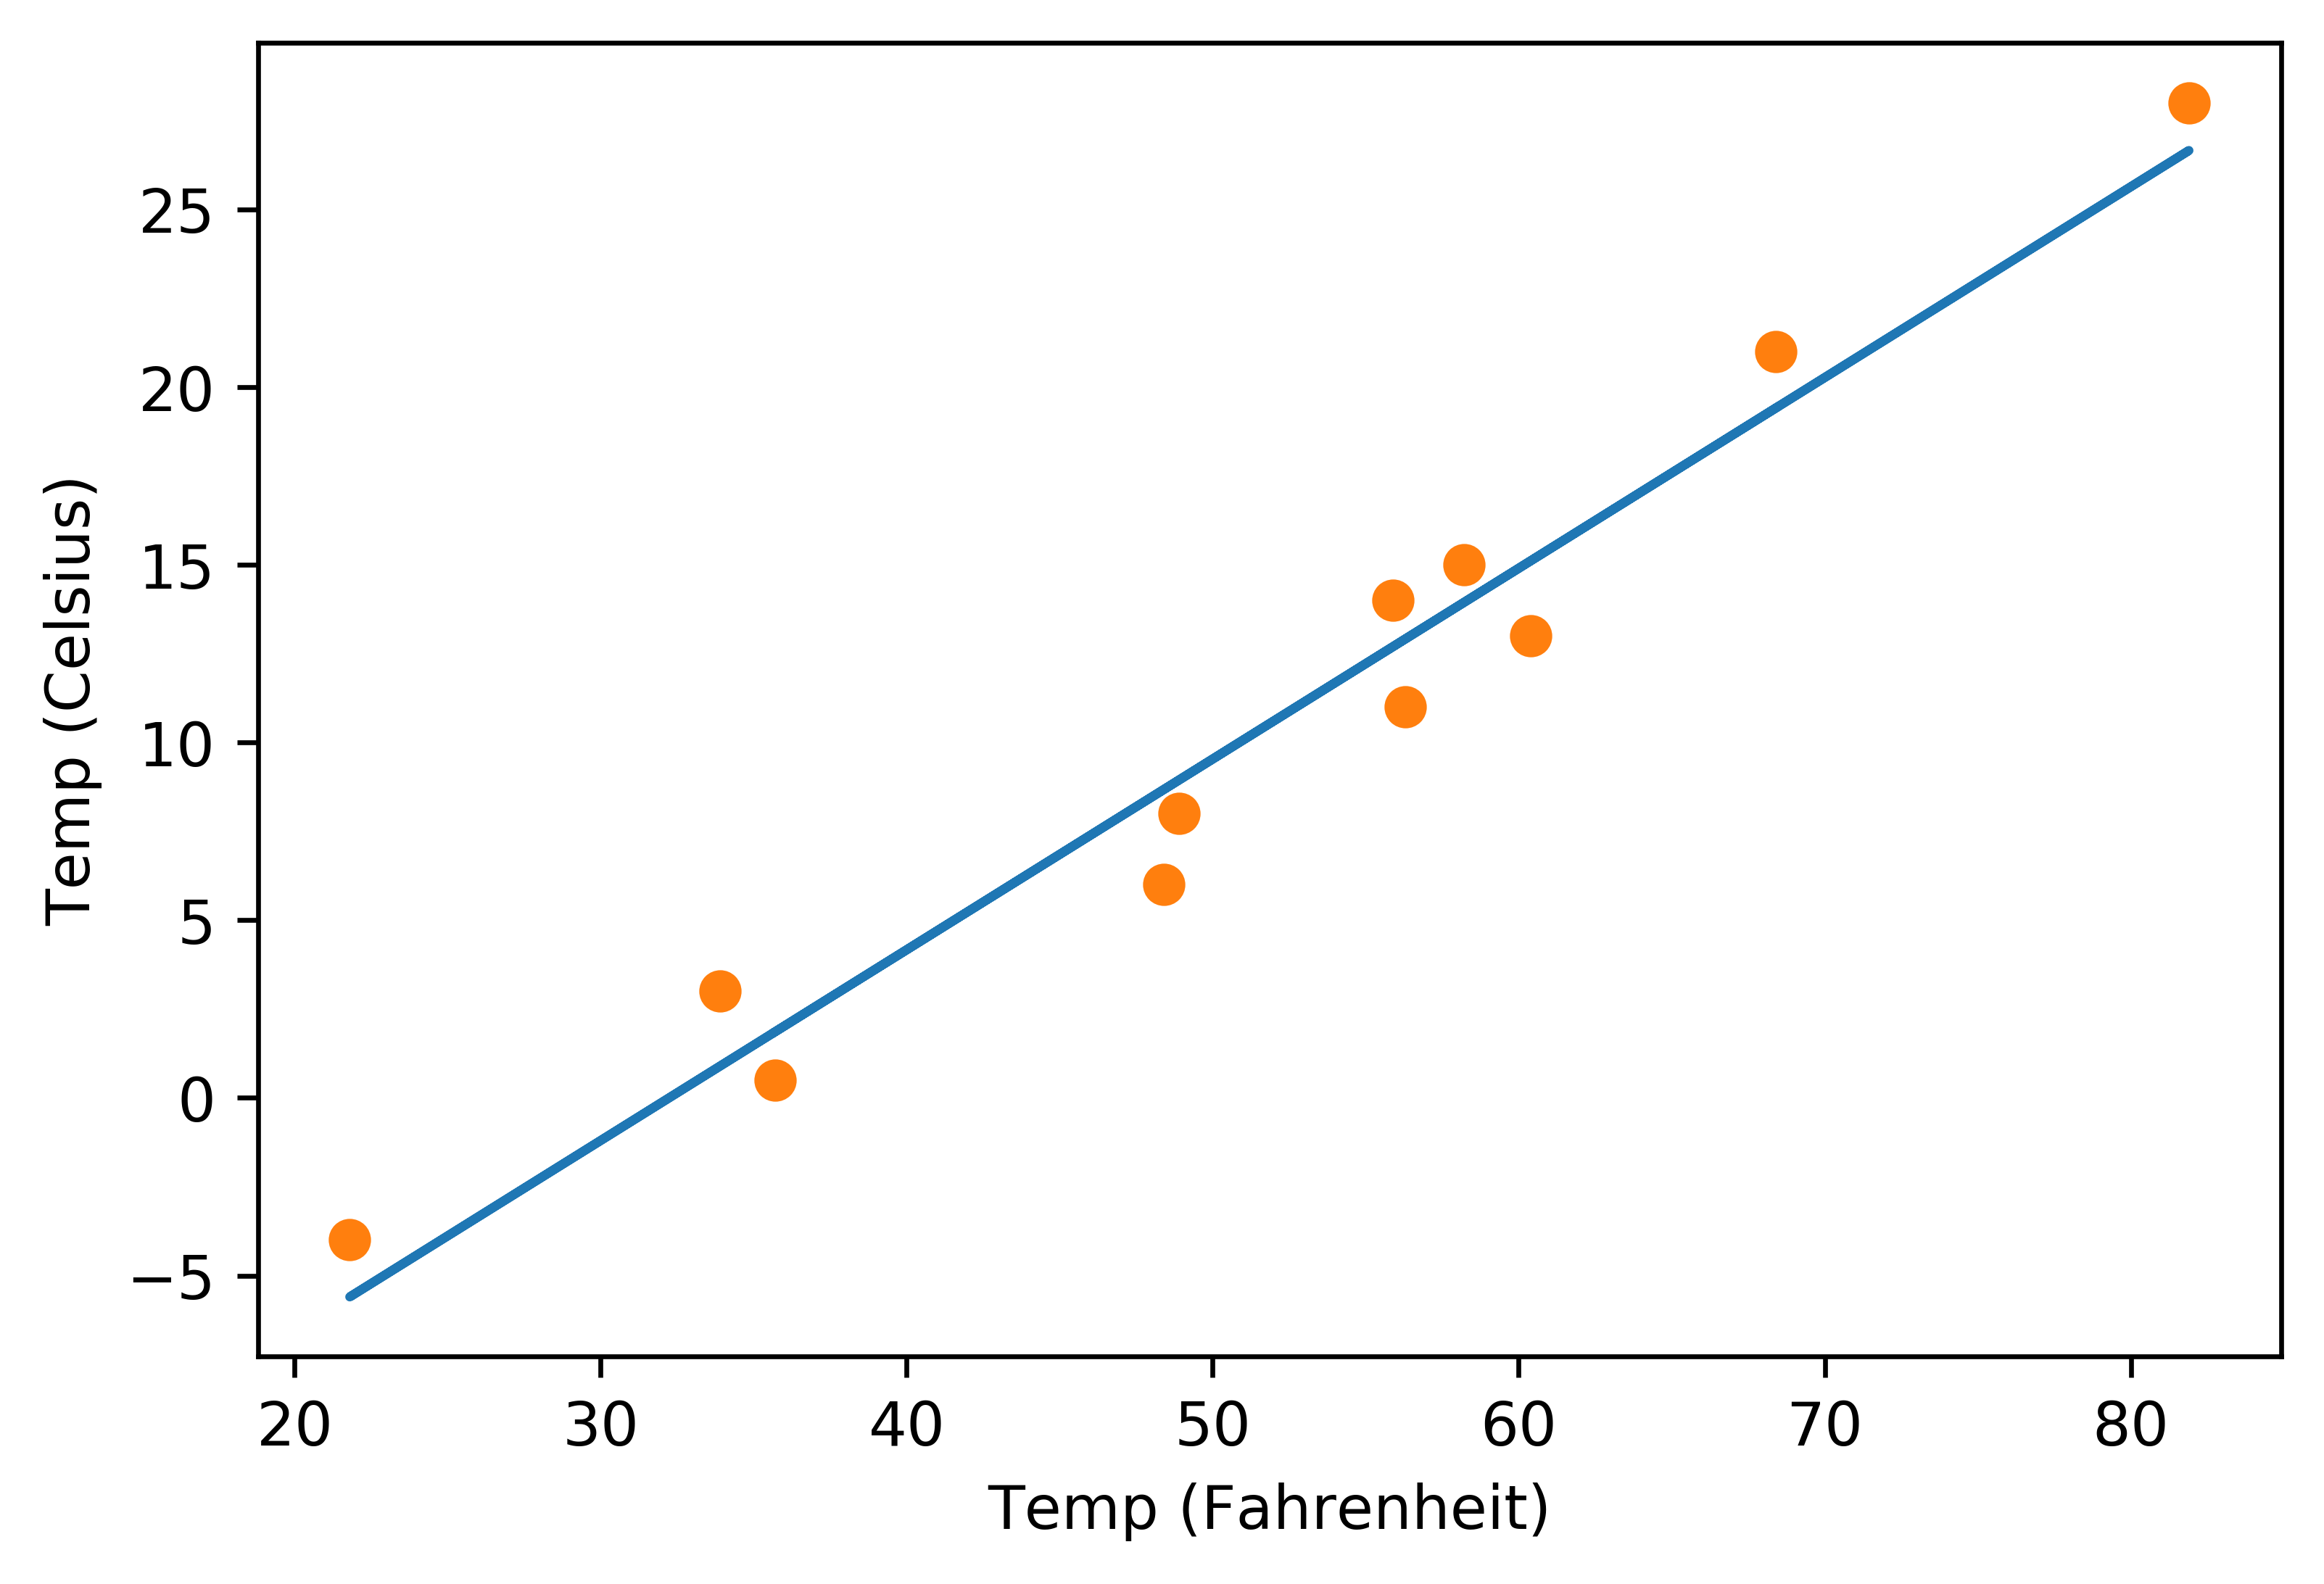

In [7]:
# visualization 
%matplotlib inline 

t_p = model(t_un, *params)
fig = plt.figure(dpi=600) 
plt.xlabel("Temp (Fahrenheit)") 
plt.ylabel("Temp (Celsius)") 
plt.plot(t_u.numpy(), t_p.detach().numpy()) 
plt.plot(t_u.numpy(), t_c.numpy(), "o") 

In [8]:
# applying autograd 
params = torch.tensor([1.0, 0.0], requires_grad=True) #requires_grad is a constructor telling pytorch to track the entire family tree of tensors from operations on params. 
params.grad is None # all pytorch tensors have an attributes named grad, which is normally non.  

loss = loss_fn(model(t_u, *params), t_c) # calling the model to compute the loss 
loss.backward() # calling the backward method on the loss tensor
params.grad # grad attribute of params contains the derivatives of the loss with respect ot each element of params. 

tensor([4517.2969,   82.6000])

In [9]:
# acculating GRAD functions  
"""
Calling backward will lead derivatives to accumulate at leaf nodes. We need to zero the gradient explicitly after using it for parameters updates. 
Zero the gradient explicitly should be done after each iteration and this can be done using the in place zero_ method. 
Eg. below 
"""

if params.grad is not None:
    params.grad.zero_() 

# rewritting training_loop function with grade and zero the gradient code above 
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs+1):
        if params.grad is not None:
            params.grad.zero_() 
        
        t_p = model(t_u, *params) 
        loss = loss_fn(t_p, t_c) 
        loss.backward()

        with torch.no_grad():
            params -= learning_rate * params.grad # updating params in place
        
        if epoch % 500 == 0:
            print("Epoch %d, Loss %f" %(epoch, float(loss)))

    return params


training_loop(n_epochs=5000, learning_rate=1e-2, params=torch.tensor([1.0,0.0], requires_grad=True), t_u=t_un, t_c=t_c)

Epoch 500, Loss 7.860116
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957697
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

In [10]:
# Optimizers a la carte
"""
Every optimizer constructor takes a list of params (pytorch tensors with requires_grad set to True) as the first input.
All params passed to the optimizer are retained inside he optimizer are retained inside the optimizer object so the optimzer can update thier values 
and access thier grad attributes. 

Optimizer exposes two methods: zero_grad and step. 
zero_grad zeros the grad attributes of all params passed upon constructions and step updates the values of those params according to the optimization strategy 
implemented by the specific optimizer. 
eg. below 
"""
params = torch.tensor([1.0, 0.0], requires_grad=True) 
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate) #params and learning rate as input for stochastic gradient descent. 

# testing the optimizer 
print("Before optimizer called: ", params)
t_p = model(t_un, *params) 
loss = loss_fn(t_p, t_c) 

optimizer.zero_grad() # call this method before loss.backward()
print("After Optimizer.zero_grad() called: ", params)
loss.backward() 
optimizer.step() # updating the params

print("After Optimzer.step() called: ", params)
print("End of Test","\n","\n")



# updating training loop function with optimizer 
def training_loop(n_epochs,optimizer, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs+1):
        t_p = model(t_u, *params) 
        loss = loss_fn(t_p, t_c)

        optimizer.zero_grad() 
        loss.backward()
        optimizer.step() 
        
        if epoch % 500 == 0:
            print("Epoch %d, Loss %f" %(epoch, float(loss)))
    
    return params

# training data with SDG Optimizer 
print("Training with SDG Optimizer")
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)
training_loop(5000, optimizer=optimizer, learning_rate=learning_rate, params=params, t_u=t_un, t_c=t_c)

Before optimizer called:  tensor([1., 0.], requires_grad=True)
After Optimizer.zero_grad() called:  tensor([1., 0.], requires_grad=True)
After Optimzer.step() called:  tensor([1.7761, 0.1064], requires_grad=True)
End of Test 
 

Training with SDG Optimizer
Epoch 500, Loss 7.860118
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957697
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927680
Epoch 4500, Loss 2.927651
Epoch 5000, Loss 2.927648


tensor([  5.3671, -17.3012], requires_grad=True)

In [11]:
# training data with Adam Optimzer on unscaled data
print("Training with Adam Optimizer")
param = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate) 
training_loop(5000, optimizer=optimizer, learning_rate=learning_rate, params=params, t_u=t_u, t_c=t_c)

Training with Adam Optimizer
Epoch 500, Loss 4.661875
Epoch 1000, Loss 4.247608
Epoch 1500, Loss 3.804648
Epoch 2000, Loss 3.425622
Epoch 2500, Loss 3.161072
Epoch 3000, Loss 3.013728
Epoch 3500, Loss 2.951061
Epoch 4000, Loss 2.931960
Epoch 4500, Loss 2.928126
Epoch 5000, Loss 2.927674


tensor([  0.5371, -17.3226], requires_grad=True)

In [12]:
# Splitting a dataset 
"""
Shuffling the elements of a tensor amounts to finding a permutation of its indicies and the randperm function does this. 

Eg below 
"""
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples) 

shuffled_indices = torch.randperm(n_samples) 
train_indices = shuffled_indices[:-n_val] # got shuffled index 
val_indices = shuffled_indices[-n_val:] # got shuffled index 
print(train_indices, val_indices)

# building train and validation set 
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]
val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

train_t_un = 0.1*train_t_u 
val_t_un = 0.1*val_t_u 



tensor([ 2,  5,  9,  1, 10,  3,  0,  6,  7]) tensor([8, 4])


In [13]:
# addding validation loss to every epoch in the training function
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs+1):
        train_t_p = model(train_t_u, *params) 
        train_loss = loss_fn(train_t_p, train_t_c)

        val_t_p = model(val_t_u, *params)
        val_loss = loss_fn(val_t_p, val_t_c)

        optimizer.zero_grad() 
        train_loss.backward() # no val_loss.backward() since don't want to train the model on the validation data
        optimizer.step() 

        if epoch <=3 or epoch % 500 == 0:
            print(f"Epochs {epoch}, Training loss {train_loss.item():.4f}, "
                f"Validation loss {val_loss.item():.4f}")
    
    return params 

params = torch.tensor([1.0, 0.0], requires_grad=True) 
learning_rate = 1e-2 
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(n_epochs=3000, optimizer=optimizer, params=params, train_t_u=train_t_un, val_t_u=val_t_un, train_t_c=train_t_c, val_t_c=val_t_c)


Epochs 1, Training loss 94.8695, Validation loss 15.0912
Epochs 2, Training loss 41.5927, Validation loss 5.0624
Epochs 3, Training loss 33.5647, Validation loss 12.8680
Epochs 500, Training loss 6.1184, Validation loss 11.9401
Epochs 1000, Training loss 2.6418, Validation loss 9.3247
Epochs 1500, Training loss 2.1846, Validation loss 8.4743
Epochs 2000, Training loss 2.1245, Validation loss 8.1789
Epochs 2500, Training loss 2.1166, Validation loss 8.0734
Epochs 3000, Training loss 2.1155, Validation loss 8.0354


tensor([  5.3613, -16.7575], requires_grad=True)

In [14]:
# updating training loop function no_grad method on val 
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs+1):
        train_t_p = model(train_t_u, *params) 
        train_loss = loss_fn(train_t_p, train_t_c) 

        with torch.no_grad():
            val_t_p = model(val_t_u, *params) 
            val_loss = loss_fn(val_t_p, val_t_c) 
            assert val_loss.requires_grad == False 
        
        optimizer.zero_grad() 
        train_loss.backward() 
        optimizer.step() 
        if epoch <=3 or epoch % 500 == 0:
            print(f"Epochs {epoch}, Training loss {train_loss.item():.4f}, "
            f"Validation loss {val_loss.item():.4f}")
    
    return params 

training_loop(n_epochs=3000, optimizer=optimizer, params=params, train_t_u=train_t_un, val_t_u=val_t_un, train_t_c=train_t_c, val_t_c=val_t_c)


Epochs 1, Training loss 2.1155, Validation loss 8.0353
Epochs 2, Training loss 2.1155, Validation loss 8.0353
Epochs 3, Training loss 2.1155, Validation loss 8.0352
Epochs 500, Training loss 2.1154, Validation loss 8.0216
Epochs 1000, Training loss 2.1154, Validation loss 8.0166
Epochs 1500, Training loss 2.1154, Validation loss 8.0149
Epochs 2000, Training loss 2.1154, Validation loss 8.0142
Epochs 2500, Training loss 2.1154, Validation loss 8.0140
Epochs 3000, Training loss 2.1154, Validation loss 8.0140


tensor([  5.3679, -16.7959], requires_grad=True)

In [15]:
def calc_forwad(t_u, t_c, params, is_train):
    with torch.set_grad_enabled(is_train):
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c) 
        
    return loss

In [16]:
# rewrting the model function and changes to learning rate and optimization

def model(t_u, w1, w2, b): #defining model 
    return w2 * t_u ** 2 + w1 * t_u +b

params = torch.tensor([1.0, 1.0, 0.0], requires_grad=True) 
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate) #changed the learning rate to adam 

training_loop(n_epochs=3000, optimizer=optimizer, params=params, train_t_u=train_t_u, val_t_u=val_t_u, train_t_c=train_t_c, val_t_c=val_t_c)



Epochs 1, Training loss 12531110.0000, Validation loss 8012097.5000
Epochs 2, Training loss 10140578.0000, Validation loss 6484824.5000
Epochs 3, Training loss 8011153.0000, Validation loss 5124233.0000
Epochs 500, Training loss 5.0806, Validation loss 4.7497
Epochs 1000, Training loss 4.1723, Validation loss 2.9730
Epochs 1500, Training loss 3.9019, Validation loss 2.0814
Epochs 2000, Training loss 3.8365, Validation loss 1.7865
Epochs 2500, Training loss 3.7884, Validation loss 1.7399
Epochs 3000, Training loss 3.7286, Validation loss 1.7653


tensor([-0.0843,  0.0058, -1.7750], requires_grad=True)